In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('/content/Extended_Employee_Performance_and_Productivity_Data.csv')
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [ ]:
#Overview
#Tổng số nhân viên
total_emp = df['Employee_ID'].nunique()
print("Total Employees:", total_emp)

Total Employees: 100000


Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64


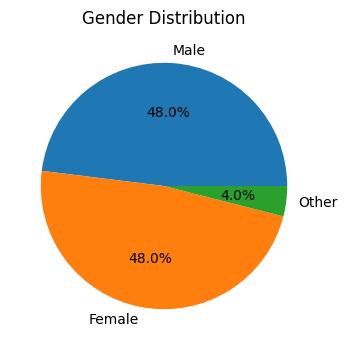

In [ ]:
#Phân bố Gender
gender_dist = df['Gender'].value_counts()
print(gender_dist)
plt.figure(figsize=(7,4))

plt.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

age_group
20-30    23031
30-40    25535
40-50    25721
50-60    25713
Name: count, dtype: int64


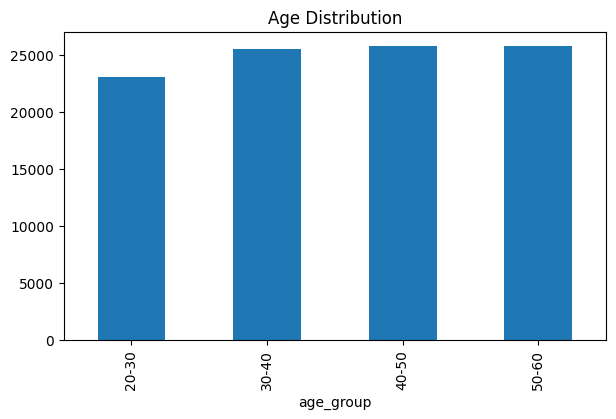

In [ ]:
# Phân bố nhóm tuổi
df['age_group'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60],
    labels=['20-30','30-40','40-50','50-60']
)

age_dist = df['age_group'].value_counts().sort_index()
print(age_dist)
plt.figure(figsize=(7,4))
age_dist.plot(kind='bar')
plt.title('Age Distribution')
plt.show()

Education_Level
Bachelor       50041
High School    30004
Master         14904
PhD             5051
Name: count, dtype: int64


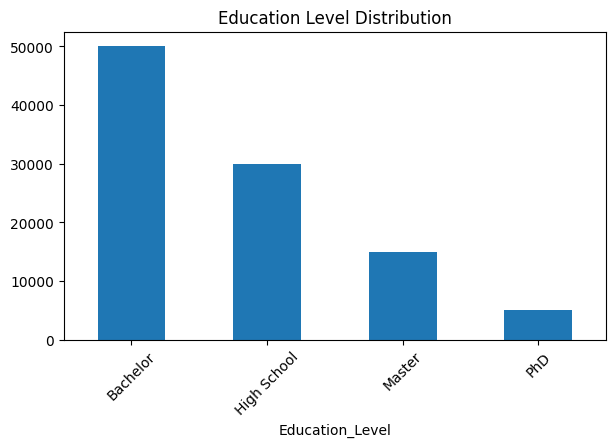

In [ ]:
#Phân bố học vấn
edu_dist = df['Education_Level'].value_counts()
print(edu_dist)
plt.figure(figsize=(7,4))
edu_dist.plot(kind='bar')
plt.title('Education Level Distribution')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Performance_Score'].unique()

array([5, 3, 2, 1, 4])

performance_group
Low       40133
Medium    39939
High      19928
Name: count, dtype: int64
performance_group
Low       40.133
Medium    39.939
High      19.928
Name: proportion, dtype: float64


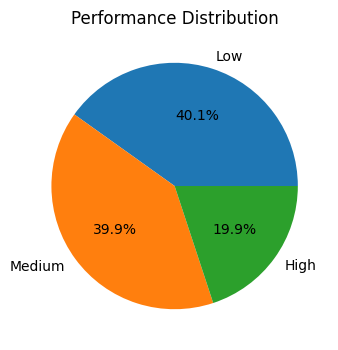

In [ ]:
#Tỷ lệ Performance Score
df['performance_group'] = pd.cut(
    df['Performance_Score'],
    bins=[0,2,4,5],
    labels=['Low','Medium','High']
)
print(df['performance_group'].value_counts())
#vẽ biểu đồ
#tính tỉ lệ
perf_dist = df['performance_group'].value_counts(normalize=True) * 100
print(perf_dist)
#biểu đồ
plt.figure(figsize=(7,4))
plt.pie(perf_dist, labels=perf_dist.index, autopct='%1.1f%%')
plt.title('Performance Distribution')
plt.show()

Dataset có 100.000 nhân viên với tỷ lệ Nam = Nữ = 48%, Other: 4%; độ tuổi từ 20-60, trình độ học vấn từ trung học -> Tiến sĩ, trong đó chủ yếu là trình độ đại học. Hiệu suất làm việc của nhân viên ghi nhận được: Low: 40,1% chiếm tỷ lệ cao nhất, Medium: 39,9%, High: 19.9% (thấp nhất) cho thấy doanh nghiệp muốn tìm hiểu điều gì ảnh hưởng đến hiệu suất nhân viên, từ đó có hành động cải thiện nhằm:
- tối ưu năng suất
- phân bổ nguồn lực, đào tạo... tốt hơn

Cleaning, EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Employee_ID                  100000 non-null  int64   
 1   Department                   100000 non-null  object  
 2   Gender                       100000 non-null  object  
 3   Age                          100000 non-null  int64   
 4   Job_Title                    100000 non-null  object  
 5   Hire_Date                    100000 non-null  object  
 6   Years_At_Company             100000 non-null  int64   
 7   Education_Level              100000 non-null  object  
 8   Performance_Score            100000 non-null  int64   
 9   Monthly_Salary               100000 non-null  float64 
 10  Work_Hours_Per_Week          100000 non-null  int64   
 11  Projects_Handled             100000 non-null  int64   
 12  Overtime_Hours               100000 non-null 

In [ ]:
#Check null
df.isnull().sum().sort_values(ascending=False)

,0
Employee_ID,0
Department,0
Gender,0
Age,0
Job_Title,0
Hire_Date,0
Years_At_Company,0
Education_Level,0
Performance_Score,0
Monthly_Salary,0


In [ ]:
#Check duplicated
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check định dạng
df.dtypes

,0
Employee_ID,int64
Department,object
Gender,object
Age,int64
Job_Title,object
Hire_Date,object
Years_At_Company,int64
Education_Level,object
Performance_Score,int64
Monthly_Salary,float64


In [ ]:
#Đổi định dạng date
df['hire_date'] = pd.to_datetime(df['Hire_Date']).dt.date

In [ ]:
df['hire_date'].head()

,hire_date
0,2022-01-19
1,2024-04-18
2,2015-10-26
3,2016-10-22
4,2021-07-23


In [ ]:
df['Employee_Satisfaction_Score'].unique()

array([2.63, 1.72, 3.17, 1.86, 1.25, 2.77, 4.46, 2.09, 1.44, 2.93, 2.34,
       1.96, 2.13, 1.46, 2.22, 2.42, 3.15, 1.19, 1.12, 3.91, 3.7 , 4.66,
       3.68, 4.26, 4.43, 2.12, 3.16, 1.35, 4.52, 4.95, 4.65, 1.95, 2.1 ,
       1.94, 4.21, 4.97, 2.47, 2.66, 4.22, 2.9 , 4.84, 3.59, 3.32, 2.53,
       1.59, 1.27, 1.47, 3.02, 1.43, 2.56, 1.1 , 1.87, 1.7 , 2.64, 3.97,
       4.23, 2.32, 2.15, 2.26, 1.68, 4.33, 2.45, 4.45, 4.49, 3.55, 1.31,
       4.98, 1.39, 1.75, 3.2 , 3.5 , 3.75, 3.4 , 1.33, 2.17, 4.27, 2.37,
       1.77, 1.11, 2.08, 3.22, 3.23, 3.69, 3.66, 4.1 , 4.36, 1.03, 4.2 ,
       4.39, 3.19, 3.42, 3.63, 5.  , 2.3 , 2.94, 2.8 , 4.68, 2.7 , 1.64,
       4.8 , 3.51, 4.5 , 3.58, 1.58, 3.24, 2.87, 4.37, 4.17, 4.47, 1.14,
       4.4 , 1.74, 1.24, 1.61, 2.84, 3.83, 3.79, 3.03, 4.83, 4.38, 3.61,
       4.61, 2.62, 1.82, 2.23, 3.3 , 4.55, 4.75, 3.  , 4.76, 1.02, 4.44,
       4.88, 3.78, 1.05, 1.79, 3.34, 4.04, 4.15, 2.85, 2.04, 1.78, 1.97,
       3.49, 4.25, 2.59, 4.72, 2.24, 3.36, 3.85, 1.

In [ ]:
#Định dạng về satisfaction về numeric
df['Employee_Satisfaction_Score'] = pd.to_numeric(
    df['Employee_Satisfaction_Score'], errors='coerce'
)

In [ ]:
#Loại bỏ giá trị satisfaction <=0
df = df[df['Employee_Satisfaction_Score'] > 0]

In [ ]:
#Làm tròn đưa về số nguyên
df['Employee_Satisfaction_Score'] = df['Employee_Satisfaction_Score'].round().astype(int)

In [ ]:
df['Employee_Satisfaction_Score'].value_counts().sort_index()

,count
Employee_Satisfaction_Score,
1,12265
2,25326
3,24926
4,25311
5,12172


In [ ]:
df['Employee_Satisfaction_Score'].unique()

array([3, 2, 1, 4, 5])

In [ ]:
#Chia nhóm satisfy
df['satisfaction_group'] = df['Employee_Satisfaction_Score'].apply(
    lambda x: 'Low' if x <= 2 else ('Medium' if x == 3 else 'High')
)

**EDA**

1. Nhóm đặc điểm cá nhân (Employee Profile) - Performance

In [ ]:
df['Performance_Score'].unique()

array([5, 3, 2, 1, 4])

In [ ]:
#Performance theo Gender
df.groupby('Gender')['Performance_Score'].mean()

,Performance_Score
Gender,
Female,2.990417
Male,2.999854
Other,3.002520


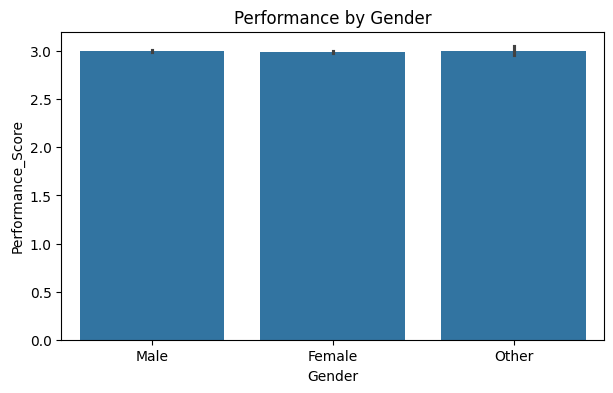

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='Gender', y='Performance_Score', data=df)
plt.title('Performance by Gender')
plt.show()

Không có sự khác biệt nhiều về giới tính - hiệu suất làm việc


In [ ]:
#Performance theo Age

df['age_group'] = pd.cut(df['Age'], bins=[20,30,40,50,60],
                         labels=['20-30','30-40','40-50','50-60'])

df.groupby('age_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/1670488700.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['Performance_Score'].mean()


,Performance_Score
age_group,
20-30,2.990925
30-40,2.993499
40-50,3.002216
50-60,2.994594


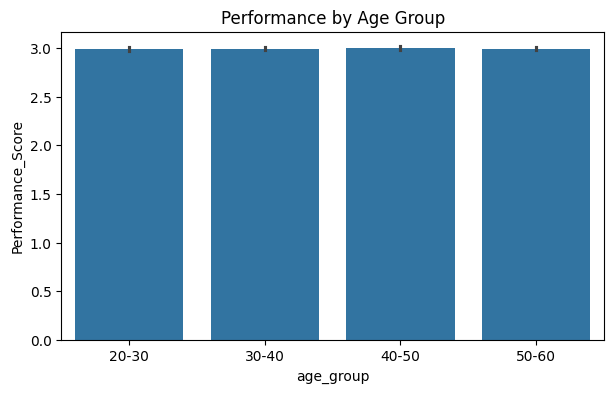

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='age_group', y='Performance_Score', data=df)
plt.title('Performance by Age Group')
plt.show()

Không có sự khác biệt rõ rệt giữa các nhóm tuổi - hiệu suất làm việc

In [ ]:
#Performance theo Experience
df.groupby('Years_At_Company')['Performance_Score'].mean()


,Performance_Score
Years_At_Company,
0,2.994843
1,2.971851
2,2.988415
3,3.011374
4,3.000396
5,3.004852
6,3.005165
7,3.001921
8,2.975906


In [ ]:
df['exp_group'] = pd.cut(df['Years_At_Company'],
                        bins=[0,2,5,10],
                        labels=['0-2','2-5','5-10'])

df.groupby('exp_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/3928374392.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('exp_group')['Performance_Score'].mean()


,Performance_Score
exp_group,
0-2,2.980237
2-5,3.005513
5-10,2.995743


Performance tăng theo kinh nghiệm → nhưng chỉ đến 2–5 năm là cao nhất
Sau đó giảm nhẹ/ ổn định.
=> Hiệu suất làm việc của nhân viên có xu hướng tăng lên theo kinh nghiệm trong giai đoạn đầu (0-5 năm), đạt đỉnh điểm ở nhóm 2-5 năm kinh nghiệm. Tuy nhiên, hiệu suất không tiếp tục tăng đáng kể sau điểm này, cho thấy hiệu ứng bão hòa.

In [ ]:
#Performance theo Job Title
df.groupby('Job_Title')['Performance_Score'].mean().sort_values(ascending=False)

,Performance_Score
Job_Title,
Specialist,3.011856
Consultant,3.003800
Engineer,2.998875
Manager,2.997208
Analyst,2.989552
Technician,2.986139
Developer,2.980275


Sự khác biệt performance giữa các job title là rất
Tất cả đều quanh ~3.0
Chênh lệch chỉ ~0.03
=> Performance không phụ thuộc mạnh vào vị trí.
Điều này cho thấy có thể: hệ thống đánh giá đang đều hoặc yếu tố khác quan trọng hơn

==> Trong số các yếu tố về đặc điểm nhân viên, kinh nghiệm có ảnh hưởng nhất định đến hiệu suất làm việc, trong khi tuổi tác, giới tính và vai trò công việc không tác động đáng kể đến mức độ hiệu suất.

2. Nhóm công việc & môi trường (Work Environment) - Performance

In [ ]:
#Work Hours per week
df['work_hours_group'] = pd.cut(
    df['Work_Hours_Per_Week'],
    bins=[0,30,40,50,100],
    labels=['<30','30-40','40-50','50+']
)

df.groupby('work_hours_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/1452287362.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('work_hours_group')['Performance_Score'].mean()


,Performance_Score
work_hours_group,
<30,3.027010
30-40,3.000553
40-50,2.996261
50+,2.986245


Càng làm nhiều giờ thì Performance giảm, làm vừa đủ thì hiệu suất tăng

In [ ]:
#Projects (Workload)
df['project_group'] = pd.cut(
    df['Projects_Handled'],
    bins=3,
    labels=['Low','Medium','High']
)

df.groupby('project_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/3091039896.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('project_group')['Performance_Score'].mean()


,Performance_Score
project_group,
Low,3.003228
Medium,2.982016
High,3.000059


Workload (Khối lượng công việc) theo số lượng projects không có ảnh hưởng rõ ràng.
Các nhóm gần như ngang nhau (~3.0)

=> Số lượng dự án đảm nhiệm không cho thấy tác động rõ rệt đến hiệu suất làm việc của nhân viên. Mức độ hiệu suất vẫn tương đối ổn định giữa các nhóm khối lượng công việc khác nhau.

In [ ]:
#Overtime
df['overtime_group'] = pd.cut(
    df['Overtime_Hours'],
    bins=3,
    labels=['Low','Medium','High']
)

df.groupby('overtime_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/4020516267.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('overtime_group')['Performance_Score'].mean()


,Performance_Score
overtime_group,
Low,2.991554
Medium,3.000629
High,2.994096


OT thấp → performance chưa tối ưu

OT vừa phải → performance cao nhất

OT cao → performance giảm

==> Làm thêm giờ ở mức độ vừa phải giúp tăng hiệu suất làm việc, trong khi làm thêm giờ quá mức có thể dẫn đến giảm hiệu quả.

In [ ]:
#Remote
df.groupby('Remote_Work_Frequency')['Performance_Score'].mean()

,Performance_Score
Remote_Work_Frequency,
0,2.983516
25,3.008747
50,2.990815
75,2.994051
100,2.999701


Remote vừa phải (25%) → performance cao nhất

full remote (100%) không vượt trội

onsite hoàn toàn (0%) thấp nhất

=> Mô hình làm việc hybrid dường như hiệu quả nhất, vì nhân viên làm việc từ xa với tần suất vừa phải đạt hiệu suất cao nhất.

In [ ]:
# Sick days
df['sick_group'] = pd.cut(
    df['Sick_Days'],
    bins=3,
    labels=['Low','Medium','High']
)

df.groupby('sick_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/3820794058.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sick_group')['Performance_Score'].mean()


,Performance_Score
sick_group,
Low,2.986357
Medium,3.002684
High,2.997282


nghỉ vừa phải → tốt hơn

nghỉ nhiều → giảm nhẹ

In [ ]:
#Team size
df['team_group'] = pd.cut(
    df['Team_Size'],
    bins=3,
    labels=['Small','Medium','Large']
)

df.groupby('team_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/430417557.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('team_group')['Performance_Score'].mean()


,Performance_Score
team_group,
Small,3.010726
Medium,2.978634
Large,2.994326


team nhỏ → hiệu suất cao hơn

team lớn → giảm nhẹ

In [ ]:
#Department
df.groupby('Department')['Performance_Score'].mean().sort_values(ascending=False)

,Performance_Score
Department,
Engineering,3.020263
Operations,3.006797
IT,3.000000
HR,2.997354
Customer Support,2.997121
Sales,2.994336
Legal,2.981741
Finance,2.981161
Marketing,2.980653


-> Mặc dù một số phòng ban như Kỹ thuật và Vận hành có hiệu suất cao hơn một chút, nhưng nhìn chung sự khác biệt giữa các phòng ban là rất nhỏ. Điều này cho thấy phòng ban không phải là yếu tố chính ảnh hưởng đến hiệu suất làm việc của nhân viên.

Ngoài ra, quy mô nhóm nhỏ hơn có thể cải thiện hiệu suất một chút, nghỉ ốm vừa phải sẽ tốt hơn nghỉ ốm nhiều, mặc dù tác động này ít đáng kể hơn so với các yếu tố liên quan đến khối lượng công việc.

==> Các yếu tố môi trường làm việc ảnh hưởng đáng kể đến hiệu suất của nhân viên. Làm việc quá nhiều giờ làm giảm hiệu quả, trong khi làm thêm giờ vừa phải và mô hình làm việc hybrid dẫn đến hiệu suất tối ưu.

Điều này nhấn mạnh tầm quan trọng của việc duy trì khối lượng công việc cân bằng và linh hoạt bao gồm giờ làm việc vừa phải, làm thêm giờ vừa phải và sử dụng
mô hình làm việc hybrid.

3. Nhóm phát triển & đào tạo (Training & Development) - Performance

In [ ]:
#Training Hours
# Chia nhóm
df['training_group'] = pd.cut(
    df['Training_Hours'],
    bins=[0,20,50,100],
    labels=['Low','Medium','High']
)
#Tính Performance
df.groupby('training_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/502810232.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('training_group')['Performance_Score'].mean()


,Performance_Score
training_group,
Low,2.995055
Medium,2.989992
High,2.998548


Training KHÔNG có ảnh hưởng rõ ràng đến performance
Số giờ đào tạo không cho thấy tác động đáng kể đến hiệu suất làm việc của nhân viên, vì mức độ hiệu suất vẫn tương đối ổn định giữa tất cả các nhóm được đào tạo.

Điều này cho thấy rằng việc chỉ đơn giản tăng số giờ đào tạo có thể không đủ để cải thiện hiệu suất, và chất lượng hoặc tính phù hợp của các chương trình đào tạo cần được xem xét.

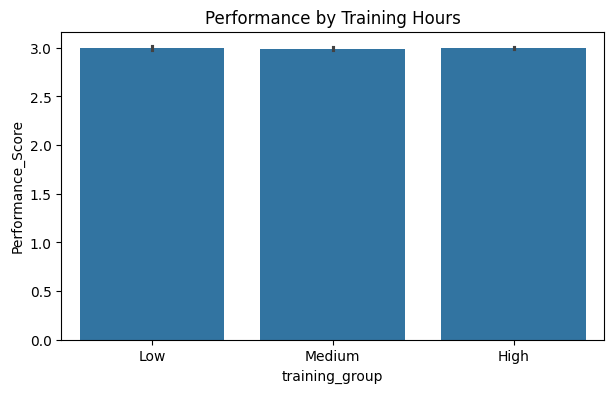

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='training_group', y='Performance_Score', data=df)
plt.title('Performance by Training Hours')
plt.show()

In [ ]:
#Promotions
df.groupby('Promotions')['Performance_Score'].mean()

,Performance_Score
Promotions,
0,3.006037
1,2.986392
2,2.993898


<Axes: xlabel='Promotions', ylabel='Performance_Score'>

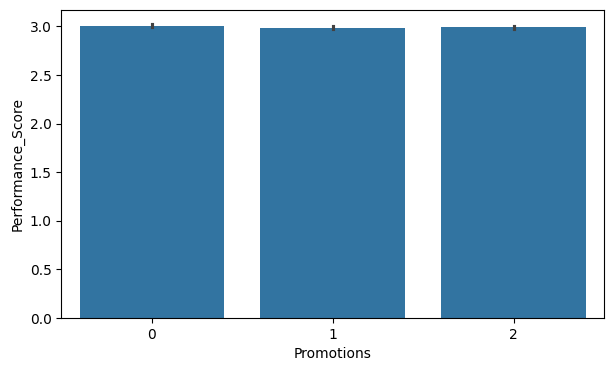

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='Promotions', y='Performance_Score', data=df)


Việc thăng chức dường như không cải thiện hiệu suất làm việc của nhân viên, và những nhân viên không được thăng chức thậm chí có thể thể hiện mức độ hiệu suất cao hơn một chút.

Việc này có thể do: việc thăng chức dựa trên: năng lực chuyên môn, thâm niên, leadership,...không phải performance hiện tại.
Sau khi thăng chức → performance giảm nhẹ, có thể do role mới khó hơn,
chưa kịp thích nghi.

Như vậy, High performer chưa chắc được promote có thể: nhân viên đang ở vị trí phù hợp chưa đến thời điểm được thăng chức.

=> quyết định thăng chức có thể bị ảnh hưởng bởi các yếu tố khác ngoài hiệu suất làm việc, hoặc nhân viên có thể cần thời gian để thích nghi với vai trò mới sau khi được thăng chức.


==> Các yếu tố đào tạo và thăng tiến không có nhiều tác động đến hiệu suất làm việc của nhân viên, thậm chí việc thăng tiến còn cho hiệu suất giảm cho thấy rằng việc đào tạo và đánh giá sự thăng tiến đơn thuần/cơ bản có thể không đủ để thúc đẩy cải thiện năng suất.

4. Nhóm động lực & đãi ngộ (Motivation) - Performance

In [ ]:
#Satisfaction
df.groupby('satisfaction_group')['Performance_Score'].mean()

,Performance_Score
satisfaction_group,
High,2.993597
Low,2.991993
Medium,3.003370


Text(0.5, 1.0, 'Performance by Satisfaction')

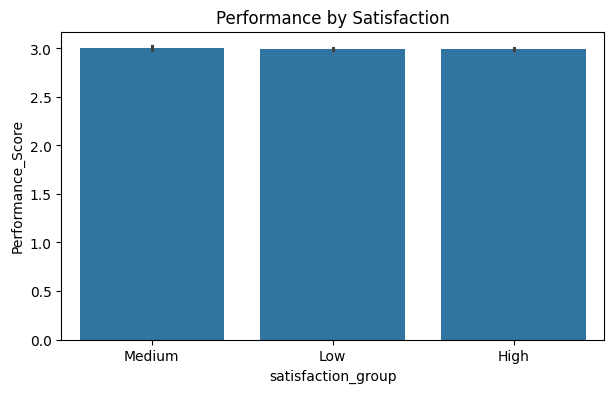

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='satisfaction_group', y='Performance_Score', data=df)
plt.title('Performance by Satisfaction')

Satisfaction không ảnh hưởng đến hiệu suất làm việc

In [ ]:
#Monthly Salary
df['salary_group'] = pd.cut(
    df['Monthly_Salary'],
    bins=3,
    labels=['Low','Medium','High']
)
df.groupby('salary_group')['Performance_Score'].mean()

/tmp/ipykernel_12641/2637052409.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('salary_group')['Performance_Score'].mean()


,Performance_Score
salary_group,
Low,2.262119
Medium,2.804140
High,4.218244


Salary là yếu tố quyết định hiệu suất làm việc

In [ ]:
df.groupby(['satisfaction_group','salary_group'])['Performance_Score'].mean()

/tmp/ipykernel_12641/2266164245.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['satisfaction_group','salary_group'])['Performance_Score'].mean()


satisfaction_group  salary_group
High                Low             2.260395
                    Medium          2.804364
                    High            4.220159
Low                 Low             2.262082
                    Medium          2.805142
                    High            4.222374
Medium              Low             2.264835
                    Medium          2.802299
                    High            4.209370
Name: Performance_Score, dtype: float64

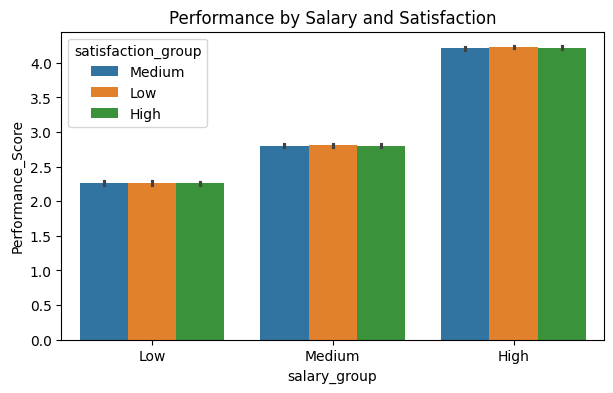

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(
    x='salary_group',
    y='Performance_Score',
    hue='satisfaction_group',
    data=df
)

plt.title('Performance by Salary and Satisfaction')
plt.show()

High satisfaction + low salary → vẫn thấp

Low satisfaction + high salary → vẫn cao

-> Mức lương có tác động chi phối mạnh mẽ đến hiệu suất làm việc, bất kể mức độ hài lòng của nhân viên như thế nào.



==> Mức lương có mối quan hệ tích cực mạnh mẽ với hiệu suất làm việc. Nhân viên có mức lương cao hơn luôn đạt được điểm hiệu suất cao hơn đáng kể, dù mức độ hài lòng của họ cao hay thấp.

Điều này cho thấy chế độ đãi ngộ tiền lương là yếu tố then chốt thúc đẩy hiệu suất làm việc của nhân viên.

5. Outcome / Behavior

In [ ]:
#Performance vs Resigned
df.groupby('Resigned')['Performance_Score'].mean()

,Performance_Score
Resigned,
False,2.996711
True,2.983916


Text(0.5, 1.0, 'Performance by Resignation Status')

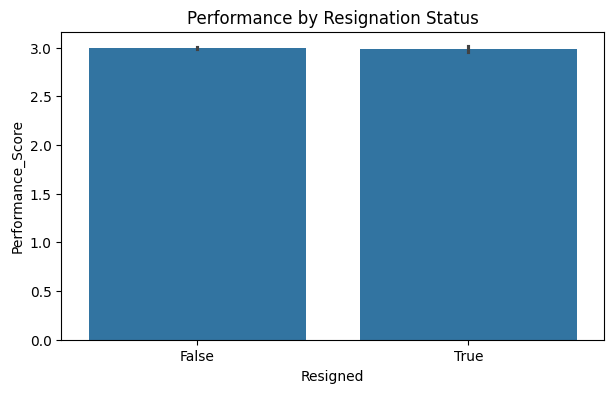

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='Resigned', y='Performance_Score', data=df)
plt.title('Performance by Resignation Status')

Không nghỉ (False): 2.997

Nghỉ (True): 2.984

->  Chênh lệch rất nhỏ (~0.013) -> Performance gần như không khác biệt giữa người nghỉ và không nghỉ

==> Không có sự khác biệt đáng kể về hiệu suất giữa những nhân viên đã nghỉ việc và những nhân viên ở lại, điều này cho thấy hiệu suất không phải là yếu tố chính dẫn đến tỷ lệ thôi việc của nhân viên.

(yếu tố về động lực và môi trường làm việc thường sẽ có tác động nhiều đến tỷ lệ thôi việc của nhân viên)

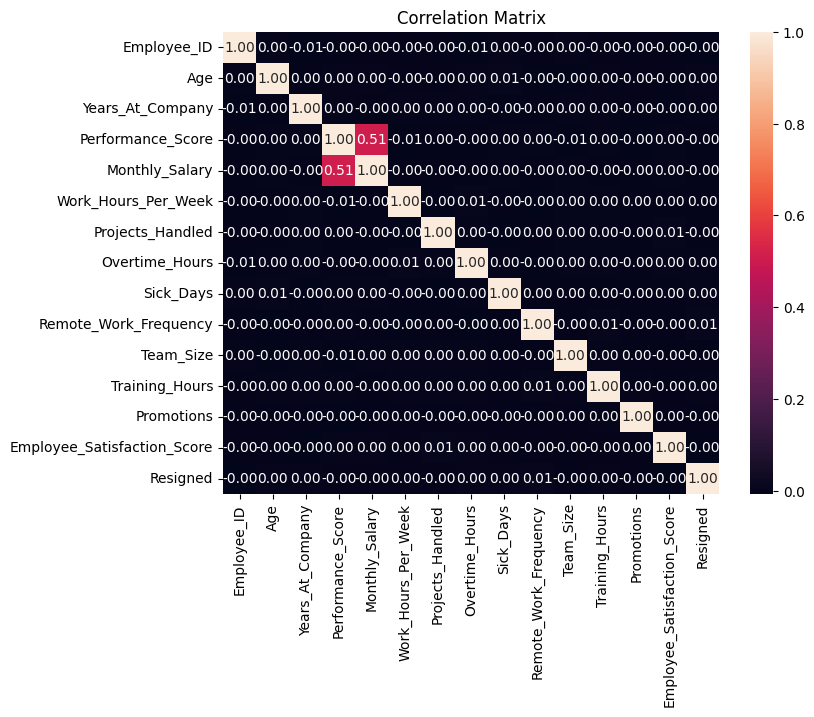

In [ ]:
#Correlation
# biến nào liên quan mạnh nhất với performance
corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

-> Monthly Salary ↔ Performance = 0.51 (tương quan cùng chiều khá mạnh).
Các biến khác gần như ~0 → không có mối liên hệ rõ ràng

In [ ]:
# Ptich hồi quy
import statsmodels.api as sm

X = df[['Monthly_Salary','Work_Hours_Per_Week','Overtime_Hours']]
y = df['Performance_Score']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance_Score   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                 1.172e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:05:50   Log-Likelihood:            -1.6152e+05
No. Observations:              100000   AIC:                         3.231e+05
Df Residuals:                   99996   BIC:                         3.231e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.3399    

-> Monthly Salary
coef = +0.0005
p-value = 0.000 < 0.05 có ý nghĩa về mặt thống kê

- Work Hours
p-value = 0.103 (>0.05) -> không có ý nghĩa thống kê

-Overtime
p-value = 0.924 -> không có ý nghĩa thống kê


Kết luận: Phân tích này cho thấy hiệu suất làm việc của nhân viên chủ yếu bị ảnh hưởng bởi môi trường làm việc và các yếu tố về tiền lương, chứ không phải các đặc điểm cá nhân hay hay do cơ hội thăng tiến bản

Trong tất cả các yếu tố, tiền lương là yếu tố quan trọng nhất ảnh hưởng đến hiệu suất, với những nhân viên được trả lương cao hơn luôn đạt được kết quả tốt hơn đáng kể bất kể mức độ hài lòng của họ cao hay thấp.

Các yếu tố môi trường làm việc cũng đóng vai trò quan trọng. Giờ làm việc quá nhiều có liên quan đến hiệu suất thấp hơn, trong khi làm thêm giờ vừa phải và mô hình làm việc hybrid góp phần vào việc  năng suất tối ưu.

Ngược lại, các đặc điểm về nhân khẩu học như tuổi tác, vị trí công việc và giới tính cho thấy tác động nhỏ đến hiệu suất. Tương tự, số giờ đào tạo và sự thăng tiến không cho thấy hiệu quả tích cực rõ rệt, cho thấy rằng chỉ riêng những hành  này có thể không cải thiện hiệu quả trong việc nâng cao hiệu suất.

Ngoài ra, tỷ lệ thôi việc của nhân viên cũng không liên quan trực tiếp đến hiệu suất, có thể rằng các yếu tố khác như tiền lương và điều kiện làm việc,... quan trọng hơn trong việc ảnh hưởng đến việc giữ chân nhân viên.

Recomendation: Dựa trên kết quả phân tích trên,

- Doanh nghiệp nên ưu tiên cải thiện chiến lược tiền lương, vì lương có tác động mạnh nhất đến hiệu suất làm việc. Đảm bảo cấu trúc trả lương cạnh tranh và công bằng có thể nâng cao đáng kể năng suất của nhân viên.

- Doanh nghiệp cũng nên tối ưu hóa điều kiện làm việc bằng cách tránh làm việc quá giờ (OT) và duy trì khối lượng công việc cân bằng. Khuyến khích làm thêm giờ ở mức độ vừa phải thay vì bắt nhân viên làm việc quá sức có thể giúp duy trì mức hiệu suất cao.

- Việc áp dụng mô hình làm việc Hybrid được khuyến nghị (Remote 25-50%), vì nó mang lại sự cân bằng và linh hoạt để tạo ra năng suất hiệu quả.

- Hơn nữa, doanh nghiệp nên đánh giá lại hiệu quả của các chương trình đào tạo và chính sách thăng tiến. Thay vì chỉ tập trung vào số lượng, cần chú trọng vào chất lượng và tính phù hợp của các kế hoạch ​​phát triển trong nội bộ.

- Để cải thiện việc giữ chân nhân viên, doanh nghiệp nên nghiên cứu thêm các yếu tố động lực và môi trường làm việc để tìm ra được vấn đề, thay vì chỉ tập trung vào các chỉ số hiệu suất làm việc.